Installing required modules

In [2]:
%pip install geopandas libpysal esda matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importing required libraries

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
import numpy as np

Loding online dataset

In [4]:
# ==============================
# 3. Load Online Vector Dataset
# ==============================

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"

world = gpd.read_file(url)

# Select Africa countries only
africa = world[world['CONTINENT'] == 'Africa']

print(africa.head())

         featurecla  scalerank  LABELRANK                        SOVEREIGNT  \
1   Admin-0 country          1          3       United Republic of Tanzania   
2   Admin-0 country          1          7                    Western Sahara   
11  Admin-0 country          1          2  Democratic Republic of the Congo   
12  Admin-0 country          1          6                           Somalia   
13  Admin-0 country          1          2                             Kenya   

   SOV_A3  ADM0_DIF  LEVEL               TYPE TLC  \
1     TZA         0      2  Sovereign country   1   
2     SAH         0      2      Indeterminate   1   
11    COD         0      2  Sovereign country   1   
12    SOM         0      2  Sovereign country   1   
13    KEN         0      2  Sovereign country   1   

                               ADMIN  ...     FCLASS_TR     FCLASS_ID  \
1        United Republic of Tanzania  ...          None          None   
2                     Western Sahara  ...  Unrecognized  Unr

Ploting African Countries Map

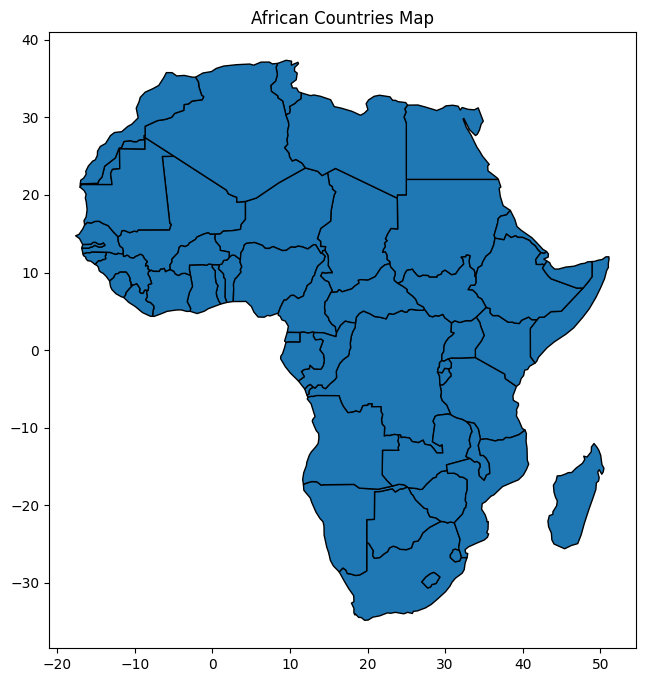

In [5]:
africa.plot(figsize=(10,8), edgecolor='black')
plt.title("African Countries Map")
plt.show()

Create Sample Attribute

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


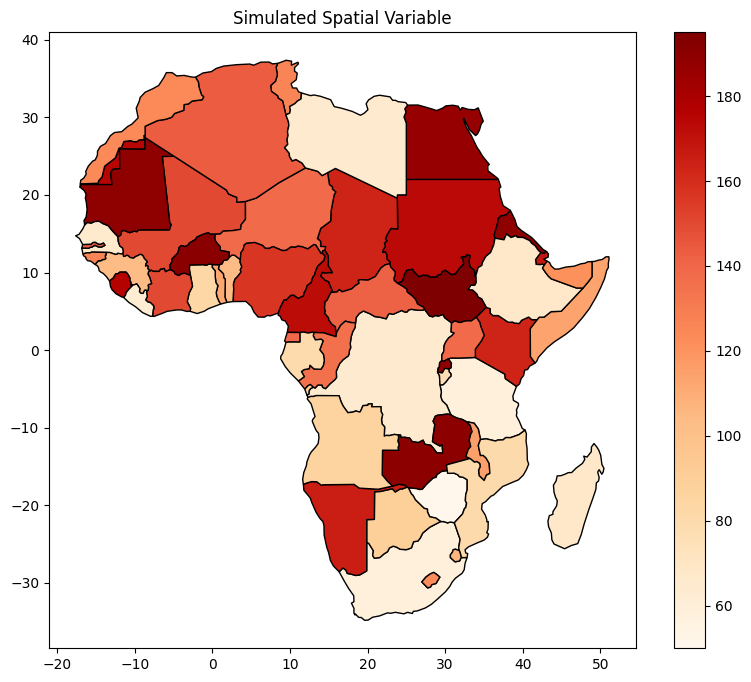

In [6]:
# ==============================
# 5. Create Example Attribute
# ==============================
# We simulate a spatial variable for analysis

np.random.seed(10)
africa["value"] = np.random.randint(50, 200, size=len(africa))

# Plot attribute distribution

africa.plot(column="value",
            cmap="OrRd",
            legend=True,
            figsize=(10,8),
            edgecolor="black")

plt.title("Simulated Spatial Variable")
plt.show()

Creating spatial weights

In [7]:
#create spatial weights matrix using Queen contiguity
w = Queen.from_dataframe(africa)
w.transform = 'r'

print("Number of neighbors for first country:", w[0])

('WARNING: ', 37, ' is an island (no neighbors)')
Number of neighbors for first country: {32: 0.125, 33: 0.125, 2: 0.125, 4: 0.125, 36: 0.125, 48: 0.125, 49: 0.125, 31: 0.125}


C:\Users\HP\AppData\Local\Temp\ipykernel_8376\3774851301.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(africa)
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 37.
  W.__init__(self, neighbors, ids=ids, **kw)


In [8]:
# 7. Global Spatial Autocorrelation
# ==============================

y = africa["value"]

moran = Moran(y, w)

print("Global Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Global Moran's I: -0.06922538393600487
p-value: 0.315


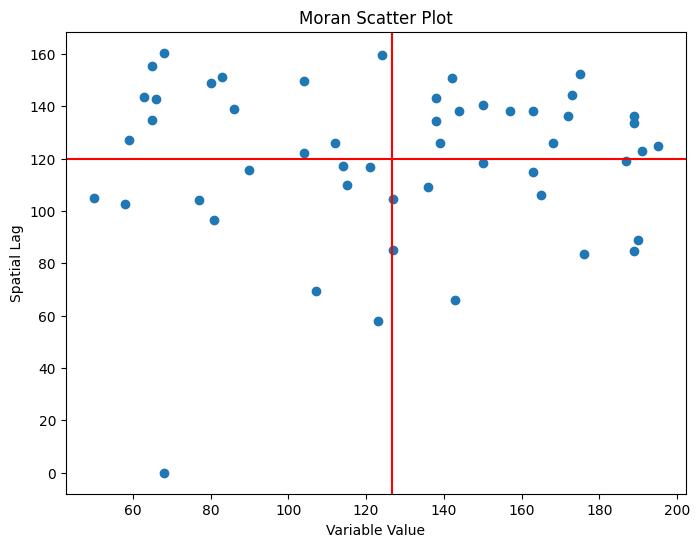

In [9]:
# 8. Moran Scatter Plot
# ==============================

from esda.moran import Moran
import seaborn as sns

lag_y = w.sparse.dot(y)

plt.figure(figsize=(8,6))
plt.scatter(y, lag_y)
plt.axhline(lag_y.mean(), color='red')
plt.axvline(y.mean(), color='red')

plt.xlabel("Variable Value")
plt.ylabel("Spatial Lag")
plt.title("Moran Scatter Plot")
plt.show()

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\esda\moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(k

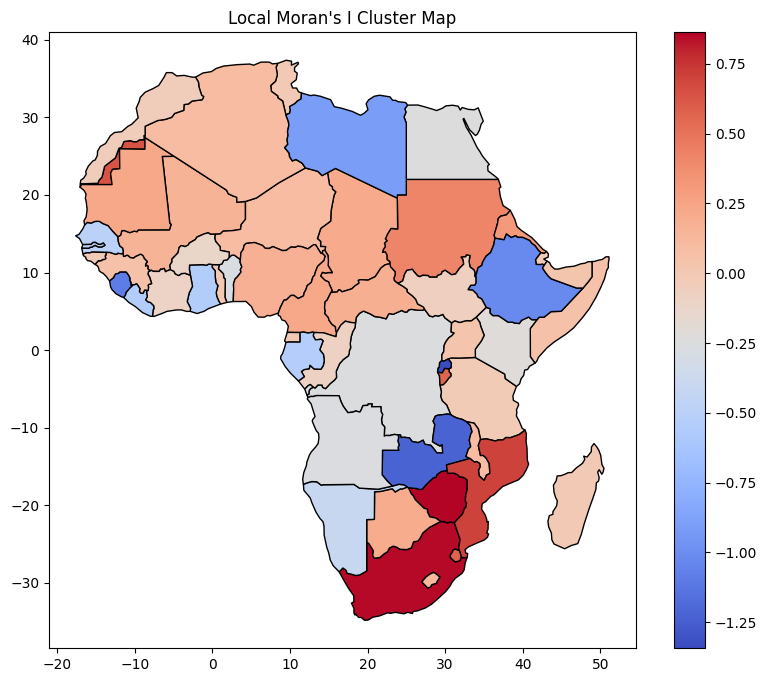

In [10]:
# 9. Local Moran's I (LISA)
# ==============================

lisa = Moran_Local(y, w)

africa['local_moran'] = lisa.Is
africa['p_value'] = lisa.p_sim

# ==============================
# 10. Map Local Spatial Clusters
# ==============================

africa.plot(column='local_moran',
            cmap='coolwarm',
            legend=True,
            figsize=(10,8),
            edgecolor='black')

plt.title("Local Moran's I Cluster Map")
plt.show()

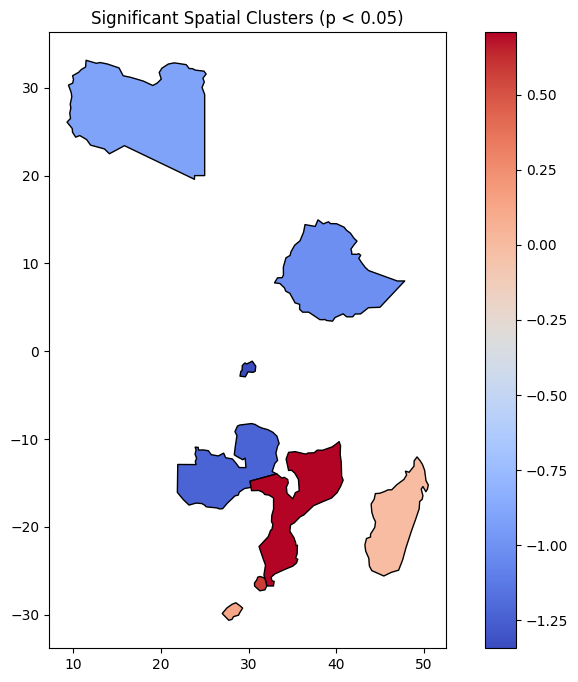

In [11]:
# 11. Significant Spatial Clusters
# ==============================

significant = africa[africa['p_value'] < 0.05]

significant.plot(column='local_moran',
                 cmap='coolwarm',
                 legend=True,
                 figsize=(10,8),
                 edgecolor='black')

plt.title("Significant Spatial Clusters (p < 0.05)")
plt.show()

In [12]:
# ==============================
# 12. Summary
# ==============================

print("Average Moran's I:", moran.I)
print("Interpretation:")
print("Positive Moran's I -> Spatial clustering")
print("Negative Moran's I -> Spatial dispersion")
print("Near zero -> Random spatial pattern")

Average Moran's I: -0.06922538393600487
Interpretation:
Positive Moran's I -> Spatial clustering
Negative Moran's I -> Spatial dispersion
Near zero -> Random spatial pattern


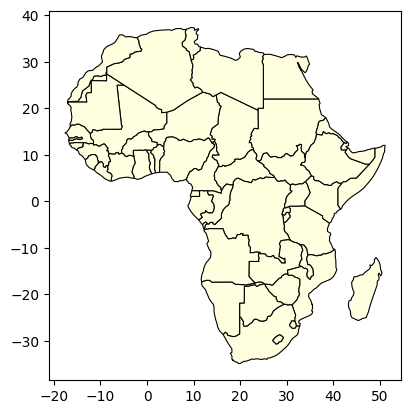

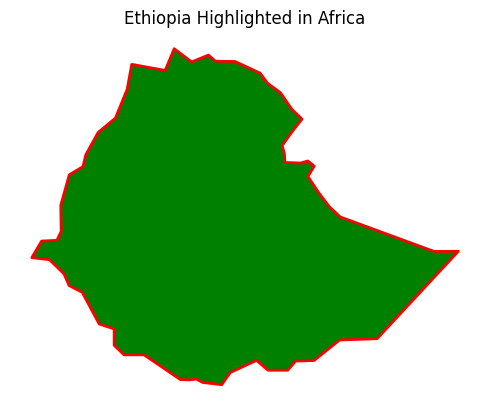

In [14]:
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
africa = gpd.read_file(url)[lambda df: df['CONTINENT'] == 'Africa']

africa.plot(color='lightyellow', edgecolor='black', linewidth=0.8)
africa[africa['ADMIN'] == 'Ethiopia'].plot(color='green', edgecolor='red', linewidth=2)
plt.title("Ethiopia Highlighted in Africa"); plt.axis('off'); plt.show()

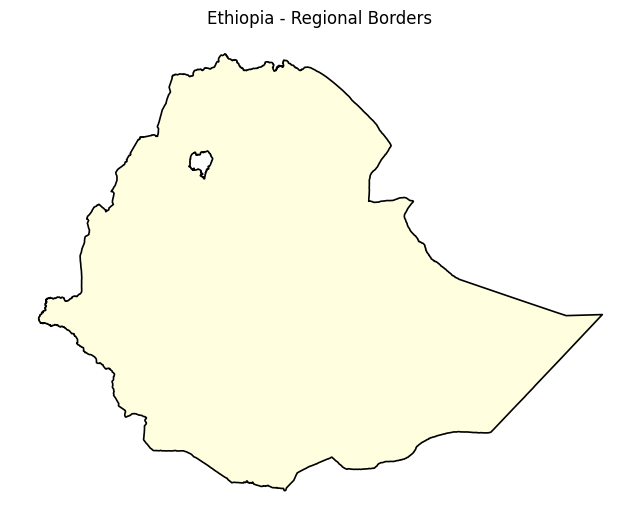

In [19]:
# Load ADM1 (regions)
regions = gpd.read_file("geoBoundaries-ETH-ADM0_simplified.geojson")

# Plot regions
fig, ax = plt.subplots(figsize=(8,10))
regions.plot(ax=ax, color='lightyellow', edgecolor='black', linewidth=1.2)
plt.title("Ethiopia - Regional Borders")
plt.axis('off')
plt.show()

In [27]:
# Only include the .shp file
districts = gpd.read_file("geoBoundaries-ETH-ADM3-all/geoBoundaries-ETH-ADM3_simplified.shp")

print(districts.head())

    shapeName shapeISO                  shapeID shapeGroup shapeType  \
0  Nefas Silk     None  50319843B72698614466884        ETH      ADM3   
1        Bole     None  50319843B25705088227224        ETH      ADM3   
2      Lideta     None  50319843B56746649263622        ETH      ADM3   
3      Kirkos     None  50319843B31296653580974        ETH      ADM3   
4        Yeka     None  50319843B65872379705117        ETH      ADM3   

                                            geometry  
0  POLYGON ((38.73862 8.99747, 38.73969 8.99174, ...  
1  POLYGON ((38.77361 8.95276, 38.77589 8.96051, ...  
2  POLYGON ((38.73862 8.99747, 38.72002 8.99961, ...  
3  POLYGON ((38.76504 8.9811, 38.75888 8.98143, 3...  
4  POLYGON ((38.8975 9.03154, 38.89062 9.02325, 3...  


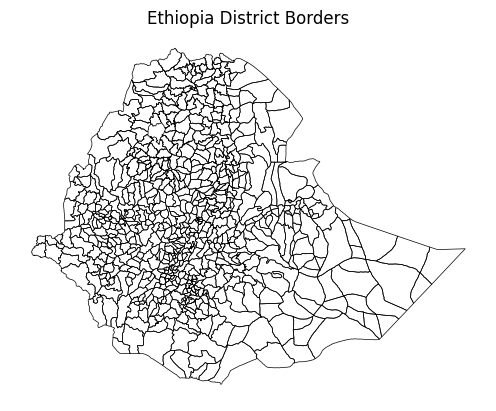

In [28]:
import matplotlib.pyplot as plt

districts.plot(color='none', edgecolor='black', linewidth=0.5)
plt.title("Ethiopia District Borders")
plt.axis('off')
plt.show()

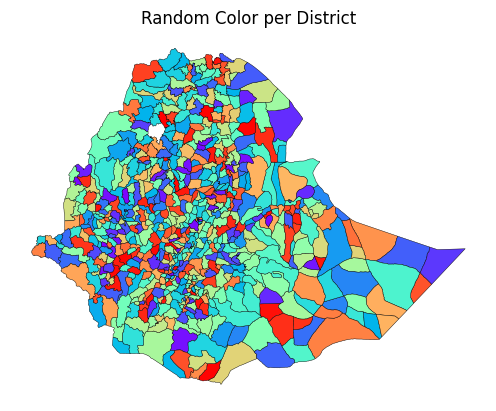

In [29]:
import numpy as np

districts['color'] = np.random.rand(len(districts))

districts.plot(column='color', cmap='rainbow', edgecolor='black', linewidth=0.3)
plt.title("Random Color per District")
plt.axis('off')
plt.show()

In [30]:
from libpysal.weights import Queen

# Create Queen contiguity weights
w = Queen.from_dataframe(districts)

# Print summary
print(w)

C:\Users\HP\AppData\Local\Temp\ipykernel_8376\3333514193.py:4: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(districts)


In [31]:
# Global Spatial Autocorrelation (Moran's I) in one cell

import geopandas as gpd
import numpy as np
from libpysal.weights import Queen
from esda.moran import Moran

# Load your districts shapefile
districts = gpd.read_file("geoBoundaries-ETH-ADM3-all/geoBoundaries-ETH-ADM3_simplified.shp")

# Create a sample variable (replace with real data if you have)
districts["value"] = np.random.rand(len(districts))

# Create spatial weights (Queen contiguity)
w = Queen.from_dataframe(districts)
w.transform = 'r'

# Compute Moran's I
y = districts["value"]
moran = Moran(y, w)

# Print results
print("Global Moran's I:", moran.I)
print("p-value:", moran.p_sim)

C:\Users\HP\AppData\Local\Temp\ipykernel_8376\555342245.py:15: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(districts)


Global Moran's I: -0.017317161887073145
p-value: 0.226


In [34]:
%pip install splot

Defaulting to user installation because normal site-packages is not writeable
  Using cached splot-1.1.7-py3-none-any.whl.metadata (8.9 kB)
  Using cached giddy-2.3.8-py3-none-any.whl.metadata (6.4 kB)
  Using cached mapclassify-2.10.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached spreg-1.9.0-py3-none-any.whl.metadata (1.7 kB)
  Using cached esda-2.8.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached quantecon-0.11.1-py3-none-any.whl.metadata (5.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached numba-0.64.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached llvmlite-0.46.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached splot-1.1.7-py3-none-any.whl (39 kB)
Using cached giddy-2.3.8-py3-none-any.whl (67 kB)
Using cached esda-2.8.2-py3-none-any.whl (157 kB)
Using cached mapclassify-2.10.0-py3-none-any.whl (88

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\HP\\AppData\\Roaming\\Python\\Python313\\site-packages\\sympy\\series\\approximants.py'
Check the permissions.


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\HP\AppData\Local\Temp\ipykernel_8376\3235197714.py:17: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(districts)


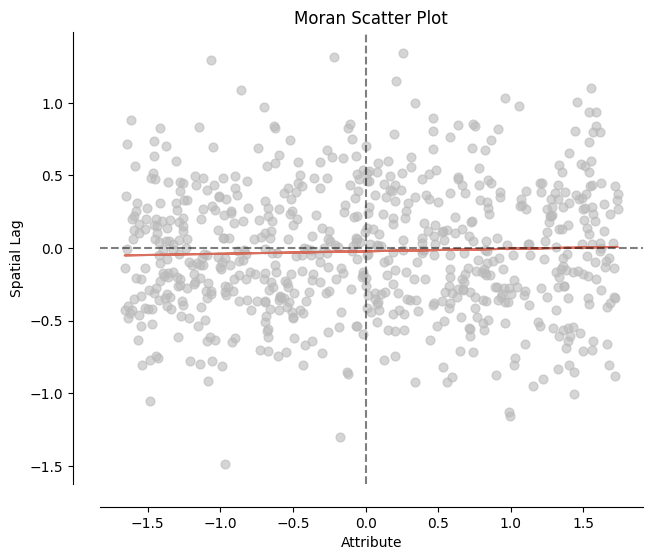

In [36]:
# Moran Scatter Plot

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import Queen
from esda.moran import Moran
from splot.esda import moran_scatterplot

# Load data
districts = gpd.read_file("geoBoundaries-ETH-ADM3-all/geoBoundaries-ETH-ADM3_simplified.shp")

# Create sample variable (replace with real data later)
districts["value"] = np.random.rand(len(districts))

# Spatial weights
w = Queen.from_dataframe(districts)
w.transform = 'r'

# Moran's I
y = districts["value"]
moran = Moran(y, w)

# Plot Moran Scatter Plot
fig, ax = moran_scatterplot(moran)
plt.title("Moran Scatter Plot")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_8376\1662236934.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(districts)


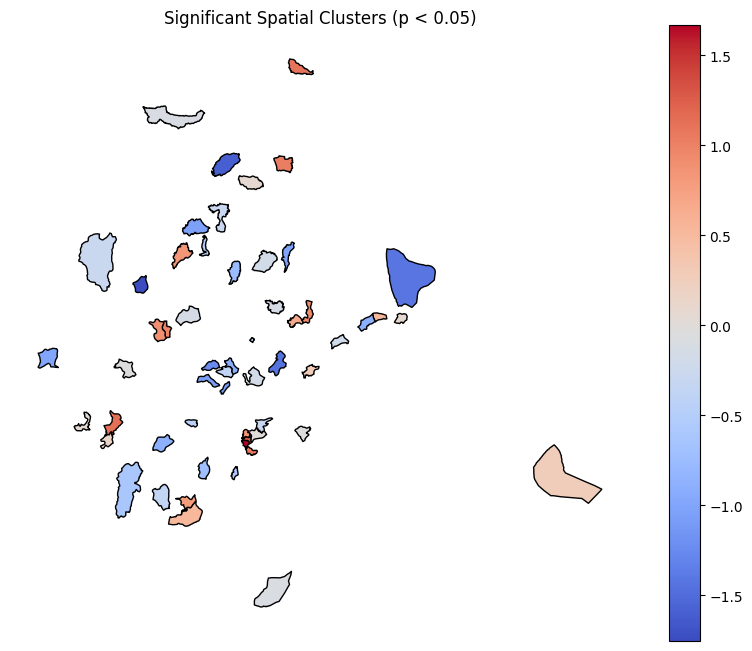

In [37]:

# Load data
districts = gpd.read_file("geoBoundaries-ETH-ADM3-all/geoBoundaries-ETH-ADM3_simplified.shp")

# Create sample variable (replace with real data)
districts["value"] = np.random.rand(len(districts))

# Spatial weights
w = Queen.from_dataframe(districts)
w.transform = 'r'

# Local Moran's I
y = districts["value"]
lisa = Moran_Local(y, w)

# Add results to dataframe
districts["local_moran"] = lisa.Is
districts["p_value"] = lisa.p_sim

# Filter significant clusters (p < 0.05)
significant = districts[districts["p_value"] < 0.05]

# Plot
significant.plot(column='local_moran',
                 cmap='coolwarm',
                 legend=True,
                 figsize=(10,8),
                 edgecolor='black')

plt.title("Significant Spatial Clusters (p < 0.05)")
plt.axis('off')
plt.show()

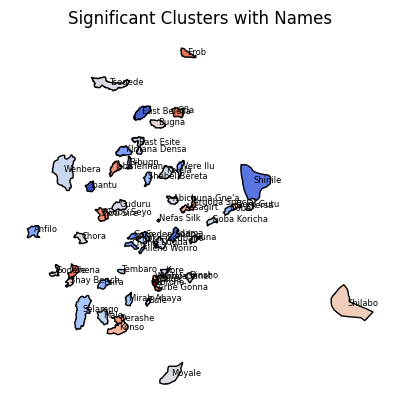

In [38]:
ax = significant.plot(column='local_moran', cmap='coolwarm', edgecolor='black')

for idx, row in significant.iterrows():
    plt.text(row.geometry.centroid.x, row.geometry.centroid.y,
             row['shapeName'], fontsize=6)

plt.title("Significant Clusters with Names")
plt.axis('off')
plt.show()

In [ ]:
# Load data
regions = gpd.read_file("geoBoundaries-ETH-ADM1.shp")
# Load data
# Load Ethiopia regions (ADM1)
#regions = gpd.read_file("geoBoundaries-ETH-ADM1.geojson")

# Check columns and names
print(regions.columns)
print(regions['shapeName'])


DataSourceError: Unable to open geoBoundaries-ETH-ADM1.shx or geoBoundaries-ETH-ADM1.SHX. Set SHAPE_RESTORE_SHX config option to YES to restore or create it.

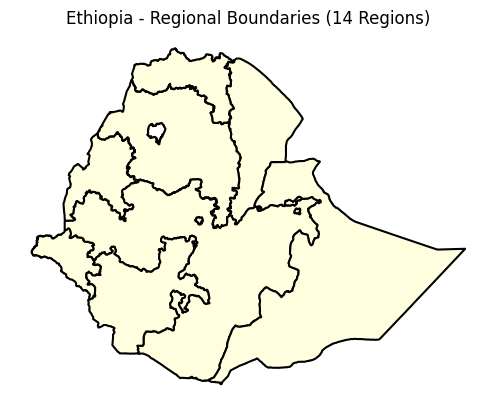

In [43]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load ADM1 regions (14 regions)
regions = gpd.read_file("geoBoundaries-ETH-ADM1.geojson")

# Plot
regions.plot(color='lightyellow', edgecolor='black', linewidth=1.5)
plt.title("Ethiopia - Regional Boundaries (14 Regions)")
plt.axis('off')
plt.show()

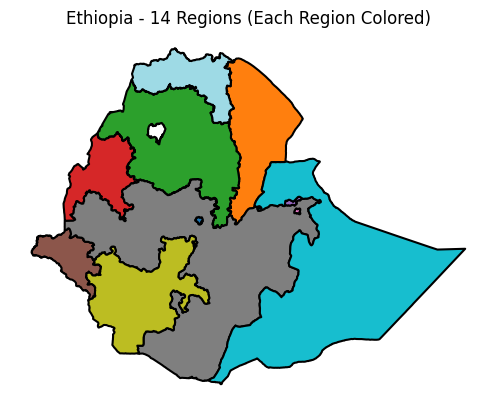

In [44]:
# Plot with different color for each region
regions.plot(
    column='shapeName',   # assign color based on region name
    cmap='tab20',         # color palette with many distinct colors
    edgecolor='black',    # borders
    linewidth=1.5,
    legend=False          # legend optional
)

plt.title("Ethiopia - 14 Regions (Each Region Colored)")
plt.axis('off')
plt.show()

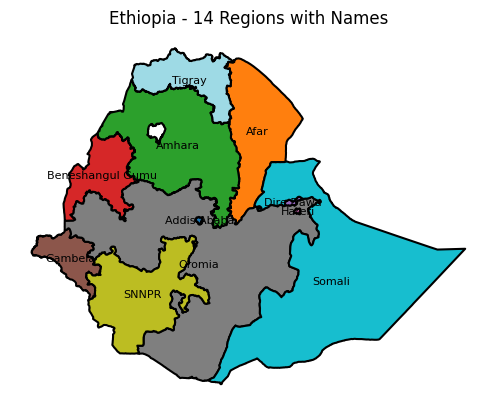

In [45]:
# Plot each region in a different color
ax = regions.plot(
    column='shapeName',
    cmap='tab20',
    edgecolor='black',
    linewidth=1.5,
    legend=False
)

# Add region names
for idx, row in regions.iterrows():
    plt.text(
        row.geometry.centroid.x,  # x-coordinate of centroid
        row.geometry.centroid.y,  # y-coordinate of centroid
        row['shapeName'],          # region name
        fontsize=8,                # text size
        ha='center',               # horizontal alignment
        va='center'                # vertical alignment
    )

plt.title("Ethiopia - 14 Regions with Names")
plt.axis('off')
plt.show()

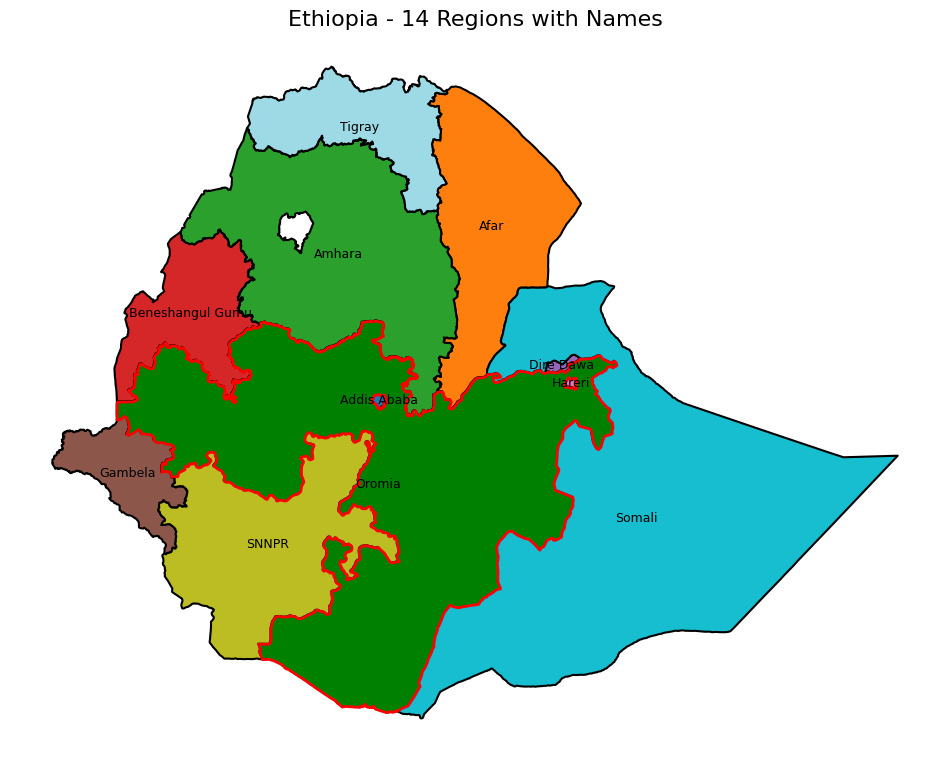

In [46]:
# Plot all regions with different colors
ax = regions.plot(
    column='shapeName',   # unique color per region
    cmap='tab20',         # color palette for 14 regions
    edgecolor='black',    
    linewidth=1.5,
    legend=False,
    figsize=(12, 10)
)

# Optional: highlight a specific region (e.g., Oromia)
regions[regions['shapeName'] == 'Oromia'].plot(
    ax=ax, color='green', edgecolor='red', linewidth=2
)

# Add region names
for idx, row in regions.iterrows():
    plt.text(
        row.geometry.centroid.x,
        row.geometry.centroid.y,
        row['shapeName'],
        fontsize=9,
        ha='center',
        va='center'
    )

plt.title("Ethiopia - 14 Regions with Names", fontsize=16)
plt.axis('off')
plt.show()